#**Tom & Jerry: The Great Cheese Chase**

---
### **Individual Project:**


**Student Name:** Amna

**Student ID:** GH1039590

**Subject code:** B144

**Submission Date:** June 2026

**Subject name:** AI Studio (SS0326)

**Course:** Data Science, AI  and Digital Business

**Institution:** Gisma University of Applied Sciences

**Project Topic:** A Reinforcement Learning Study Using Q-Learning and Deep Q-Networks


**GitHub Repository:** *(add your repository link here)*

---


#**Summary**

###**Introduction**
This report documents an original reinforcement learning project in Python that uses a custom 16×18 grid-world house environment, called "Tom & Jerry: Chasing Cheese.
RL agent (Jerry the mouse) has to find 10 pieces of cheese objects in a house, while avoiding the blocking Tom the cat, which is chasing the RL agent with the Breadth-First Search (BFS) pathfinding algorithm.

**Two RL algorithms are implemented and compared:**

- **Q-Learning**-tabular table with Q-table based on dictionary and Manhattan distance heuristic for firing actions

- **Deep Q-Network (DQN)**-
with a target network, experience replay, and a three layer PyTorch neural network as the Q-table.

Two RL algorithms are implemented and compared, namely Q-Learning, using a tabular table with a dictionary based Q-table and a heuristic based on Manhattan distance for selecting actions to take, and a Deep Q-Network (DQN) with a three layer PyTorch neural network as Q-table, a target network, and experience replay.

The agents are trained in 3,000 episodes at moderate difficulty level (Tom delay = 4).

This version incorporates seven levels of difficulty with which to share via my GitHub Pages

Results show that in the later stages of learning, DQN has superior performance, but in the early stages Q-Learning learns faster. The trained agent's win rate decreases monotonically with Tom's speed for all seven difficulties which provides a clear indication that the game difficulty adaptivity is working, and that the learned policy is valid at least under stress.

In [ ]:
import numpy as np
import copy
import random
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque
from matplotlib.colors import LinearSegmentedColormap


warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

print("Imports worked")
print(f"Torch version:", torch.__version__)
print(f"NumPy version: {np.__version__}")
print("Using GPU ", torch.cuda.is_available())

Imports worked
Torch version: 2.11.0+cpu
NumPy version: 2.0.2
Using GPU  False


#**The Game Environment Design**

###**2.1 The House — Grid Layout**

The environment is a 16-row × 18-column grid (288 cells total) based directly on the maze used in the playable browser game. Each cell is either an open floor tile (0) or an impassable wall (1). The wall layout creates distinct rooms and corridors, resembling the interior of a house from a top down perspective.

### **2.2 State Representation**


The state must uniquely describe Jerry's position and the current collection status of all ten cheese pieces because the optimal strategy for an uncollected cheese changes once nearby cheese has already been picked up. The state is encoded as a single integer combining both pieces of information via a bitmask:



 ***state = (jerry_row × 18 + jerry_col) × $2^{10}$ + cheese_mask***




For the DQN agent, the state is encoded as three normalised floating-point values

Jerry's row divided by 15, Jerry's column divided by 17, and the fraction of cheese collected (0 to 1) which are better suited as neural network inputs than a large integer index.

###**2.3 Action Space**

| Action | Direction | Effect |
|--------|---------|---------|
| 0 | Up | (-1, 0) |
| 1 | Down | (+1, 0)
| 2 | Left | (0, -1) |
| 3 | Right | (0, +1) |

###**2.4 Reward Structure**

| Event | Reward | Purpose for Design |
|--------|---------|---------|
| Cheese piece collected | +50 | Incremental positive signal for progress |
| All 10 cheese collected (win) | +300(bonus) | Strong signal for completing the full goal
| Tom catches Jerry | -100 | Strong failure penalty |
| Normal step on open floor | -0.5 | Efficiency pressure-Discourages wandering
| wall collision | -5 | Discourages bumping into walls repeatedly |


### **2.5 Tom's Ai- BFS Pathfinding**

Tom the cat is not an RL one, but he is using a deterministic algorithm, called Breadth-First Search (BFS). For each time that Tom should move (according to the delay parameter)

BFS is used to find a shortest path between Tom's current position and Jerry's current position, and Tom takes the first move on the shortest path.

###**2.6 Game Levels**
The game is a playable browser game which has 7 stages in which Tom gradually increases his speed. Delay system has the same time as RL training, which is training for difficulty delayed.

| Level | Tom | Delay | Cheese target |
|--------|---------|---------|---------|
| 1 | sleepy tom |J(8 steps)->T(1 steps)| 5 |
| 2 | yawming tom | J(6 steps)->T(1 steps) | 6 |
| 3 | strectching tom | J(5 steps)->T(1 steps) |7 |
| 4 | strotting tom | J(4 steps)->T(1 steps) | 8 |
| 5 | jogging tom | J(3 steps)->T(1 steps) | 9 |
| 6 | running tom | J(2 steps)->T(1 steps) | 10 |
| 7 | sprinting tom | J(1 steps)->T(1 steps) | 10 |


In [ ]:
class TomJerryEnv:
    # this is my maze design-
    #1 means wall
    #0 means walkway
    GRID = [
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
        [1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1],
        [1,0,1,0,1,0,1,1,0,1,1,0,1,0,1,1,0,1],
        [1,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1],
        [1,0,1,1,1,1,0,1,1,1,0,1,1,1,0,1,0,1],
        [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1],
        [1,1,1,0,1,1,1,0,1,1,1,0,1,1,0,1,0,1],
        [1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1],
        [1,0,1,0,0,0,1,1,0,0,0,0,1,1,0,1,0,1],
        [1,0,1,1,1,0,1,0,0,1,1,0,1,0,0,1,0,1],
        [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
        [1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1],
        [1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,1],
        [1,0,1,1,0,1,1,1,0,1,1,1,0,1,1,1,0,1],
        [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
        [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],
    ]

    # Here we are positioning the cheese
    CHEESE_POS = [
        (1,2),(1,8),(1,13),(3,5),(5,9),
        (7,5),(8,10),(10,4),(10,12),(14,9),
    ]
    def __init__(self, tom_delay=6):

        #when jery moves=8 steps; tom moves=1 steps
        #when Jery moves=8 steps; tom moves=1 stepst
        self.rows       = 16
        self.cols       = 18
        self.n_actions  = 4
        self.n_cheese   = len(self.CHEESE_POS)
        self.tom_delay  = tom_delay

        self.grid = np.array(self.GRID)


        self.action_map = {
            0: (-1,  0),   # Up
            1: ( 1,  0),   # Down
            2: ( 0, -1),   # Left
            3: ( 0,  1),   # Right
        }

        #calculating the total
        self.n_states = self.rows * self.cols * (2 ** self.n_cheese)


        self.jerry_pos    = [1, 1]
        self.tom_pos      = [14, 16]
        self.cheese_mask  = 0
        self.tom_counter  = 0

    def _encode(self, jerry_pos, cheese_mask):
        pos = jerry_pos[0] * self.cols + jerry_pos[1]
        return pos * (2**self.n_cheese) + cheese_mask

    def get_state(self):
        return self._encode(self.jerry_pos, self.cheese_mask)

#positioning of grid
#checking if hits the
    def _is_wall(self, r, c):
        if r < 0 or r >= self.rows or c < 0 or c >= self.cols:
            return True
        return self.grid[r, c] == 1

#Manhattan math formula
    def manhattan(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

#tom finding path
    def _bfs_step(self, start, goal):
        if start == goal:
            return None

        visited = {tuple(start)}
        queue = deque([(start, [])])

#shift movement choices
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

        while queue:
            pos, path = queue.popleft()

            for dr, dc in directions:
                next_pos = (pos[0] + dr, pos[1] + dc)

                if next_pos not in visited and not self._is_wall(next_pos[0], next_pos[1]):
                    new_path = path + [list(next_pos)]

                    if list(next_pos) == goal:
                        return new_path[0]

                    visited.add(next_pos)
                    queue.append((next_pos, new_path))

        return None


    def reset(self):
        self.jerry_pos = [1, 1]
        self.tom_pos = [14, 16]

    # Reseting cheese
        self.cheese_mask = 0
        self.tom_counter = 0

        return self.get_state()


    def step(self, action):
    #changing row and column
        change_in_row, change_in_col = self.action_map[action]

        next_jerry_row = self.jerry_pos[0] + change_in_row
        next_jerry_col = self.jerry_pos[1] + change_in_col

        reward = -0.5

    #jerry movement
        if self._is_wall(next_jerry_row, next_jerry_col):
            reward = -5.0
        else:
            self.jerry_pos = [next_jerry_row, next_jerry_col]

        for i in range(self.n_cheese):
            cheese_row, cheese_col = self.CHEESE_POS[i]

            if next_jerry_row == cheese_row and next_jerry_col == cheese_col:

                if not ((self.cheese_mask >> i) & 1):
                    self.cheese_mask = self.cheese_mask | (1 << i)
                    reward += 50.0
    #rewards
    #checking if jerry won
        winning_mask = (2 ** self.n_cheese) - 1
        if self.cheese_mask == winning_mask:
            reward += 300.0
            return self.get_state(), reward, True, {'result': 'win'}

    #tom movement
        self.tom_counter += 1
        if self.tom_counter >= self.tom_delay:

            self.tom_counter = 0
            next_tom_spot = self._bfs_step(self.tom_pos, self.jerry_pos)

            if next_tom_spot is not None:
                self.tom_pos = next_tom_spot

    #checking if tom caught jery
        if self.tom_pos == self.jerry_pos:

    #game over
            return self.get_state(), -100.0, True, {'result': 'caught'}

    #game still going
        return self.get_state(), reward, False, {'result': 'ongoing'}

    def render(self):

        print("\n  🏠  TOM & JERRY HOUSE")
        print("  " + "─"*36)
        for r in range(self.rows):
            row = "  |"
            for c in range(self.cols):
                if   [r,c] == self.jerry_pos: row += "J"
                elif [r,c] == self.tom_pos:   row += "T"
                elif any(cr==r and cc==c and not(self.cheese_mask>>i&1)
                         for i,(cr,cc) in enumerate(self.CHEESE_POS)):
                    row += "C"
                elif self.grid[r,c] == 1:     row += "█"
                else:                          row += "·"
            print(row + "|")
        print("  " + "─"*36)
        collected = bin(self.cheese_mask).count('1')
        print(f"  J=Jerry  T=Tom  C=Cheese  █=Wall")
        print(f"  Cheese: {collected}/{self.n_cheese}  |  "
              f"Tom delay: {self.tom_delay} steps\n")

#quick test
print("─"*55)
print("ENVIRONMENT TEST")
print("─"*55)
env_test = TomJerryEnv(tom_delay=6)
s = env_test.reset()
print(f"State space size  : {env_test.n_states:,}")
print(f"Jerry starts at   : {env_test.jerry_pos}")
print(f"Tom starts at     : {env_test.tom_pos}")
print(f"Cheese locations  : {env_test.CHEESE_POS}")
print(f"Starting state ID : {s}")
env_test.render()
s2, r2, done2, info2 = env_test.step(1)
print(f"Jerry moved Down → reward={r2:.1f}  done={done2}  info={info2}")

───────────────────────────────────────────────────────
ENVIRONMENT TEST
───────────────────────────────────────────────────────
State space size  : 294,912
Jerry starts at   : [1, 1]
Tom starts at     : [14, 16]
Cheese locations  : [(1, 2), (1, 8), (1, 13), (3, 5), (5, 9), (7, 5), (8, 10), (10, 4), (10, 12), (14, 9)]
Starting state ID : 19456

  🏠  TOM & JERRY HOUSE
  ────────────────────────────────────
  |██████████████████|
  |█JC·█···C·█··C···█|
  |█·█·█·██·██·█·██·█|
  |█·█··C·█····█····█|
  |█·████·███·███·█·█|
  |█········C·····█·█|
  |███·███·███·██·█·█|
  |█···█C····█··█···█|
  |█·█···██··C·██·█·█|
  |█·███·█··██·█··█·█|
  |█···C·······C····█|
  |█·██·██·██·██·██·█|
  |█··█··█··█·······█|
  |█·██·███·███·███·█|
  |█········C······T█|
  |██████████████████|
  ────────────────────────────────────
  J=Jerry  T=Tom  C=Cheese  █=Wall
  Cheese: 0/10  |  Tom delay: 6 steps

Jerry moved Down → reward=-0.5  done=False  info={'result': 'ongoing'}


---
#**3. RL Algorithm Implementation**

The Q-Learning algorithm is an off-policy model-free RL. It stores a Q-table (implemented as a Python dictionary, Q), such that entry
`Q[(state, action)]` is the expected total future reward (recall that T is a time horizon) one could receive by taking action a from state s and following the derived policy.


Each pair (state, action) is given a value of 0 in the Q-table (implicitly, according to the default ascribed to the dictionary). The entry after each transition is updated with the **Bellman equation**:

> **Q(s, a) ← Q(s, a) + α [r + γ · maxₐ' Q(s', a') − Q(s, a)]**

> **α = 0.15 (learning rate)  γ = 0.95 (discount factor)**


The term in square brackets *[r + γ · max Q(s') − Q(s,a)]*   is the temporal difference (TD) error, which is the difference between the current guess and the "better guess" using the reward just obtained and the "best guess" of future reward. At each step, the multiplication by α determines how much to change.

The state space is 294,912, which is too large to store in a NumPy array not because most of the entries are not set to zero, but because the number of states which never have been visited would also occupy significant space. Only states that the agent had experience in will be stored in the dictionary.

###**3.2 Epsilon-Greedy Exploration**

One of the fundamental RL problems is the exploration exploitation tradeoff.


### **3.3 Manhattan Distance Evasion Heuristic**

The evasion heuristic, which was directly inspired by the technique used in the reference project called `manhattan_dist()` is a critical addition.
In early episodes if Tom did not catch Jerry he would have no cheese collection experience for his Q-table to learn from otherwise he can catch Jerry with a single move in.



This is how Jerry's definition of 0.88 using Q-Learning.



---



#**4. Q-Learning Agent**


This defines how Jerry thinks using Q-Learning.

**Bellman Equation (the update rule):**
```
Q(s,a) = Q(s,a) + α × [reward + γ × best_future_Q − Q(s,a)]
```
- **α = 0.15** — learning rate (how fast to update)
- **γ = 0.95** — discount factor (care about future rewards)
- **ε decays** from 1.0 → 0.05 (explore → exploit)
- **Evasion heuristic** — if Tom is within distance 3, run away!

Implementing the RL AlgorithmIn third chapter, implementing the RL Algorithm was studied.
The algorithm is called RL (model-free, off-policy) and it is known as Q-Learning.


In [ ]:
class QAgent:
  #learning rate, discount factor,
  #exploration rate, how fast this stops

    def __init__(self, env, alpha=0.15, gamma=0.95,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.997):

        self.env           = env
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.q = {}

    def _qval(self, s, a):
        return self.q.get((s, a), 0.0)

    def _best_action(self, s):
        vals = [self._qval(s, a) for a in range(self.env.n_actions)]
        return int(np.argmax(vals))

    def choose_action(self, state):


        dist = self.env.manhattan(self.env.jerry_pos,
                                   self.env.tom_pos)
        if dist <= 3:
            best_a, best_d = None, -1
            for a in range(self.env.n_actions):
                dr, dc = self.env.action_map[a]
                nr = self.env.jerry_pos[0] + dr
                nc = self.env.jerry_pos[1] + dc
                if not self.env._is_wall(nr, nc):
                    d = self.env.manhattan([nr,nc], self.env.tom_pos)
                    if d > best_d:
                        best_d = d
                        best_a = a
#70% chance to use evasion when Tom is close
            if best_a is not None and random.random() < 0.7:
                return best_a

#normal epsilon
        if random.random() < self.epsilon:
            return random.randint(0, self.env.n_actions - 1)
        return self._best_action(state)

    def update(self, s, a, r, s2, done):

        old_q  = self._qval(s, a)
        target = r if done else (
            r + self.gamma * max(self._qval(s2, aa)
                                 for aa in range(self.env.n_actions)))
        self.q[(s, a)] = old_q + self.alpha * (target - old_q)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

print('Q-Agent class')


Q-Agent class


###**Train Q-Learning Jerry**

This is designed to run the real training loop. Takes 1–3 minutes. Watch the avg reward go UP as Jerry learns!

In [ ]:
def train_qlearning(n_episodes=3000, max_steps=500, tom_delay=4):
    env    = TomJerryEnv(tom_delay=tom_delay)
    agent  = QAgent(env)
    ep_rewards = []
    wins = 0

    print("─"*55)
    print(f"🐭  TRAINING Q-LEARNING JERRY")
    print(f"    Episodes : {n_episodes}  |  Max steps : {max_steps}")
    print(f"    Tom delay: {tom_delay} (Tom moves every {tom_delay} Jerry steps)")
    print("─"*55)

    for ep in range(n_episodes):
        s = env.reset()
        total_r = 0

        for _ in range(max_steps):
            a              = agent.choose_action(s)
            s2, r, done, info = env.step(a)
            agent.update(s, a, r, s2, done)
            s       = s2
            total_r += r
            if done:
                if info['result'] == 'win':
                    wins += 1
                break

        agent.decay_epsilon()
        ep_rewards.append(total_r)

        if (ep + 1) % 500 == 0:
            last = ep_rewards[-500:]
            print(f"  Ep {ep+1:5d} | Avg: {np.mean(last):8.2f} "
                  f"| ε: {agent.epsilon:.3f} "
                  f"| Wins: {wins} "
                  f"| Q-entries: {len(agent.q):,}")

    print(f"\n Q-Learning done!  Jerry wins: {wins}/{n_episodes}")
    return agent, ep_rewards, wins, env

q_agent, q_rewards, q_wins, env_q = train_qlearning(
    n_episodes=3000, max_steps=500, tom_delay=4)


───────────────────────────────────────────────────────
🐭  TRAINING Q-LEARNING JERRY
    Episodes : 3000  |  Max steps : 500
    Tom delay: 4 (Tom moves every 4 Jerry steps)
───────────────────────────────────────────────────────
  Ep   500 | Avg:    69.81 | ε: 0.223 | Wins: 177 | Q-entries: 24,883
  Ep  1000 | Avg:   599.33 | ε: 0.050 | Wins: 564 | Q-entries: 25,647
  Ep  1500 | Avg:   624.39 | ε: 0.050 | Wins: 960 | Q-entries: 25,929
  Ep  2000 | Avg:   637.25 | ε: 0.050 | Wins: 1362 | Q-entries: 25,940
  Ep  2500 | Avg:   648.98 | ε: 0.050 | Wins: 1777 | Q-entries: 26,469
  Ep  3000 | Avg:   698.42 | ε: 0.050 | Wins: 2226 | Q-entries: 26,469

 Q-Learning done!  Jerry wins: 2226/3000


### **3.4 Deep Q-Network (DQN)**

The network does not need to look up Q(s,a) in a dictionary, but computes it as a differentiable function of the input state.
This lets the network say that positions that are similar should have similar Q-values.


The online network is kept frozen 2. to Target Cell: The target value is set to be the same as the one used for the Bellman target, which is `target = r + γ · max Q_target(s')`. The weights on the frozen copy are replaced by the new weight available over the Internet every 200 steps. If not, then every step of the network would be chasing a moving target, and inducing oscillation or divergence.

> **Loss function:** `L(θ) = E[ (r + γ · maxₐ' Q̂(s', a'; θ⁻) − Q(s, a; θ))² ]`

> Online weights of the network θ, Frozen weights of the target network θ⁻ (frozen every 200 steps)




















###**3.5 Hyperparameter Table**

| Parameter | Q-Learning | DQN | Purpose |
|---|---|---|---|
| Episodes | 3,000 | 3,000 | Total training games |
| Max steps/ep | 500 | 500 | Episode time limit |
| Tom delay (training) | 4 | 4 | Moderate difficulty |
| α (learning rate) | 0.15 | 0.0005 (Adam) | Update magnitude |
| γ (discount) | 0.95 | 0.95 | Future reward weight |
| ε start → min | 1.0 → 0.05 | 1.0 → 0.05 | Exploration schedule |
| ε decay/episode | ×0.997 | ×0.997 | Exploration reduction |
| Evasion threshold | dist ≤ 3 | dist ≤ 3 | Tom proximity trigger |
| Memory size | — | 20,000 | Replay buffer |
| Batch size | — | 64 | Mini-batch training |
| Target update | — | 200 steps | Target network copy |
| Network layers | — | 3→128→128→4 | Architecture |







---


## **DQN Neural Network**





In DQN, Q-Learning is decomposed into a Q-table and an NN is used to substitute Q-table.


The network architecture is:


**Network architecture:**
```
Input (3 floats) → 128 neurons → ReLU → 128 neurons → ReLU → Output (4 Q-values)
```

There are two ways of doing this, both of them stability techniques:

- **Experience Replay** — This stores 20,000 past moves trains on random batches of 64

- **Target Network** — frozen copy that is updated every 200 steps for stable training `target = r + γ · max Q_target(s')`.

- **Adam optimizer** — lr=0.0005





In [ ]:
class TomJerryNet(nn.Module):
#3 neural network- DQN Jerry
#removing negative and raw q values
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 4)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        output = self.layer3(x)
        return output

#DQN Agent tracking memory

class DQNAgent:
    def __init__(self, env, lr=0.0005, gamma=0.95, epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.997, memory_size=20000, batch_size=64, target_update=200):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.step_count = 0
#replaying memory
#usage of gpu
#online and target network is mentioned
#adam optimizer
        self.memory = deque(maxlen=memory_size)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.online_net = TomJerryNet().to(self.device)
        self.target_net = copy.deepcopy(self.online_net).to(self.device)
        self.target_net.eval()

        self.optimizer = optim.Adam(self.online_net.parameters(), lr=lr)

    def convert_state_to_tensor(self, state_id):
        total_cheese_combos = 2 ** self.env.n_cheese
        cheese_mask = state_id % total_cheese_combos
        flat_position = state_id // total_cheese_combos

        row = flat_position // self.env.cols
        col = flat_position % self.env.cols

        cheeses_eaten = 0
        for i in range(self.env.n_cheese):
            if (cheese_mask >> i) & 1:
                cheeses_eaten += 1

        normalized_row = row / (self.env.rows - 1)
        normalized_col = col / (self.env.cols - 1)
        normalized_cheese = cheeses_eaten / self.env.n_cheese

        state_features = [normalized_row, normalized_col, normalized_cheese]
        return torch.tensor(state_features, dtype=torch.float32, device=self.device)

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def choose_action(self, state):
#panic evasion
#best escape actionm
#measuring distances
        distance_to_tom = self.env.manhattan(self.env.jerry_pos, self.env.tom_pos)
        if distance_to_tom <= 3:
            best_escape_action = None
            max_distance_found = -1
            for a in range(self.env.n_actions):
                dr, dc = self.env.action_map[a]
                next_row = self.env.jerry_pos[0] + dr
                next_col = self.env.jerry_pos[1] + dc
                if not self.env._is_wall(next_row, next_col):
                    potential_dist = self.env.manhattan([next_row, next_col], self.env.tom_pos)
                    if potential_dist > max_distance_found:
                        max_distance_found = potential_dist
                        best_escape_action = a
            if best_escape_action is not None and random.random() < 0.7:
                return best_escape_action

#epsilon
        if random.random() < self.epsilon:
            return random.randint(0, self.env.n_actions - 1)
        else:
            state_tensor = self.convert_state_to_tensor(state).unsqueeze(0)
            with torch.no_grad():
                predicted_q_values = self.online_net(state_tensor)
                best_action = predicted_q_values.argmax().item()
                return best_action

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return

        random_batch = random.sample(self.memory, self.batch_size)

        states_list, actions_list, rewards_list, next_states_list, dones_list = [], [], [], [], []
        for sample in random_batch:
            states_list.append(sample[0])
            actions_list.append(sample[1])
            rewards_list.append(sample[2])
            next_states_list.append(sample[3])
            dones_list.append(sample[4])

        states_tensor = torch.stack([self.convert_state_to_tensor(s) for s in states_list])
        next_states_tensor = torch.stack([self.convert_state_to_tensor(s2) for s2 in next_states_list])

        actions_tensor = torch.tensor(actions_list, dtype=torch.long, device=self.device)
        rewards_tensor = torch.tensor(rewards_list, dtype=torch.float32, device=self.device)
        dones_tensor = torch.tensor(dones_list, dtype=torch.float32, device=self.device)

        all_current_q_predictions = self.online_net(states_tensor)
        current_q_values = all_current_q_predictions.gather(1, actions_tensor.unsqueeze(1)).squeeze()

        with torch.no_grad():
            all_next_q_predictions = self.target_net(next_states_tensor)
            max_future_q_values = all_next_q_predictions.max(1)[0]
            target_q_values = rewards_tensor + (1 - dones_tensor) * self.gamma * max_future_q_values

        loss = F.mse_loss(current_q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = self.epsilon * self.epsilon_decay
        if self.epsilon < self.epsilon_min:
            self.epsilon = self.epsilon_min

#only training after collecting collected enough experiences
#processing arrays
def train_dqn(n_episodes=3000, max_steps=500, tom_delay=4):
    env = TomJerryEnv(tom_delay=tom_delay)
    agent = DQNAgent(env)
    all_episode_rewards = []
    total_wins = 0

    print("─"*55)
    if torch.cuda.is_available():
        print("STARTING DQN-TRAINING (Device: GPU/CUDA)")
    else:
        print("STARTING DQN-TRAINING (Device: CPU)")
    print(f"Total Rounds: {n_episodes} | Max Moves: {max_steps} | Tom Delay: {tom_delay}")
    print("─"*55)
    for episode in range(n_episodes):
        current_state = env.reset()
        episode_reward_accumulator = 0

        for step in range(max_steps):
            action_to_take = agent.choose_action(current_state)
            next_state, reward, done, info = env.step(action_to_take)
            agent.remember(current_state, action_to_take, reward, next_state, done)
            agent.train_step()

            current_state = next_state
            episode_reward_accumulator += reward
            if done:
                if info['result'] == 'win':
                    total_wins += 1
                break

        agent.decay_epsilon()
        all_episode_rewards.append(episode_reward_accumulator)

        if (episode + 1) % 500 == 0:
            last_500_rewards = all_episode_rewards[-500:]
            print(f"Round {episode+1:4d}/{n_episodes} "
                  f"| Avg Score: {np.mean(last_500_rewards):7.2f} "
                  f"| Epsilon: {agent.epsilon:.3f} "
                  f"| Total Wins: {total_wins} "
                  f"| Memory Size: {len(agent.memory)}")

    print(f"Deep Q-Network Done! Jerry won {total_wins}/{n_episodes} rounds.")
    return agent, all_episode_rewards, total_wins, env


#training deep learning models
dqn_agent, dqn_rewards, dqn_wins, env_dqn = train_dqn(n_episodes=3000, max_steps=500, tom_delay=4)

───────────────────────────────────────────────────────
STARTING DQN-TRAINING (Device: CPU)
Total Rounds: 3000 | Max Moves: 500 | Tom Delay: 4
───────────────────────────────────────────────────────
Round  500/3000 | Avg Score: -336.22 | Epsilon: 0.223 | Total Wins: 15 | Memory Size: 20000
Round 1000/3000 | Avg Score: -130.00 | Epsilon: 0.050 | Total Wins: 27 | Memory Size: 20000
Round 1500/3000 | Avg Score:    9.12 | Epsilon: 0.050 | Total Wins: 71 | Memory Size: 20000
Round 2000/3000 | Avg Score:   84.39 | Epsilon: 0.050 | Total Wins: 111 | Memory Size: 20000
Round 2500/3000 | Avg Score:   51.57 | Epsilon: 0.050 | Total Wins: 132 | Memory Size: 20000
Round 3000/3000 | Avg Score:   90.68 | Epsilon: 0.050 | Total Wins: 217 | Memory Size: 20000
Deep Q-Network Done! Jerry won 217/3000 rounds.


---
# **4. Experiments and Results**


The agents were trained for 3000 episodes at a difficulty setting `(Tom delay = 4), level 4`, which is considered difficult.
The episodes of the positions were recorded.


The total reward of both agents increases as epsilon decreases and the Q-table and neural network learns more, trending towards being more rewarding at being closer to collecting cheese.

The type of tabular updates are directly used, which leads to quick initial improvement in performance, as a single experience can directly correct the exact Q-value for `(state, action)` associated with it, as in Q-Learning.

###**Training Plots**
Plots 6 graphs of the learning of both agents as it will be shown below. The figure (`tomjerry_final_analysis_curves.png`) is the figure referred to in the results discussion in this report:
*raw rewards, smoothed learning curves, win rate over training, house map, house comparison, and estimated cheese collection rate.*


--------------------------------------------------
Summary of Experimental Outcomes
--------------------------------------------------

* Model Settings                  : Tabular Q-Learning
Initial Score Mean(First 500)   :    69.81
Final Score Mean (Last 500)     :   698.42
Final Score Mean                : +628.61
Total Successful Evaluated Runs : 2226/3000 Wins
Win Rate                        : 74.2%

* Model Settings                  : (DQN)
Initial Score Mean(First 500)   :  -336.22
Final Score Mean (Last 500)     :    90.68
Final Score Mean                : +426.89
Total Successful Evaluated Runs : 217/3000 Wins
Win Rate                        : 7.2%
--------------------------------------------------


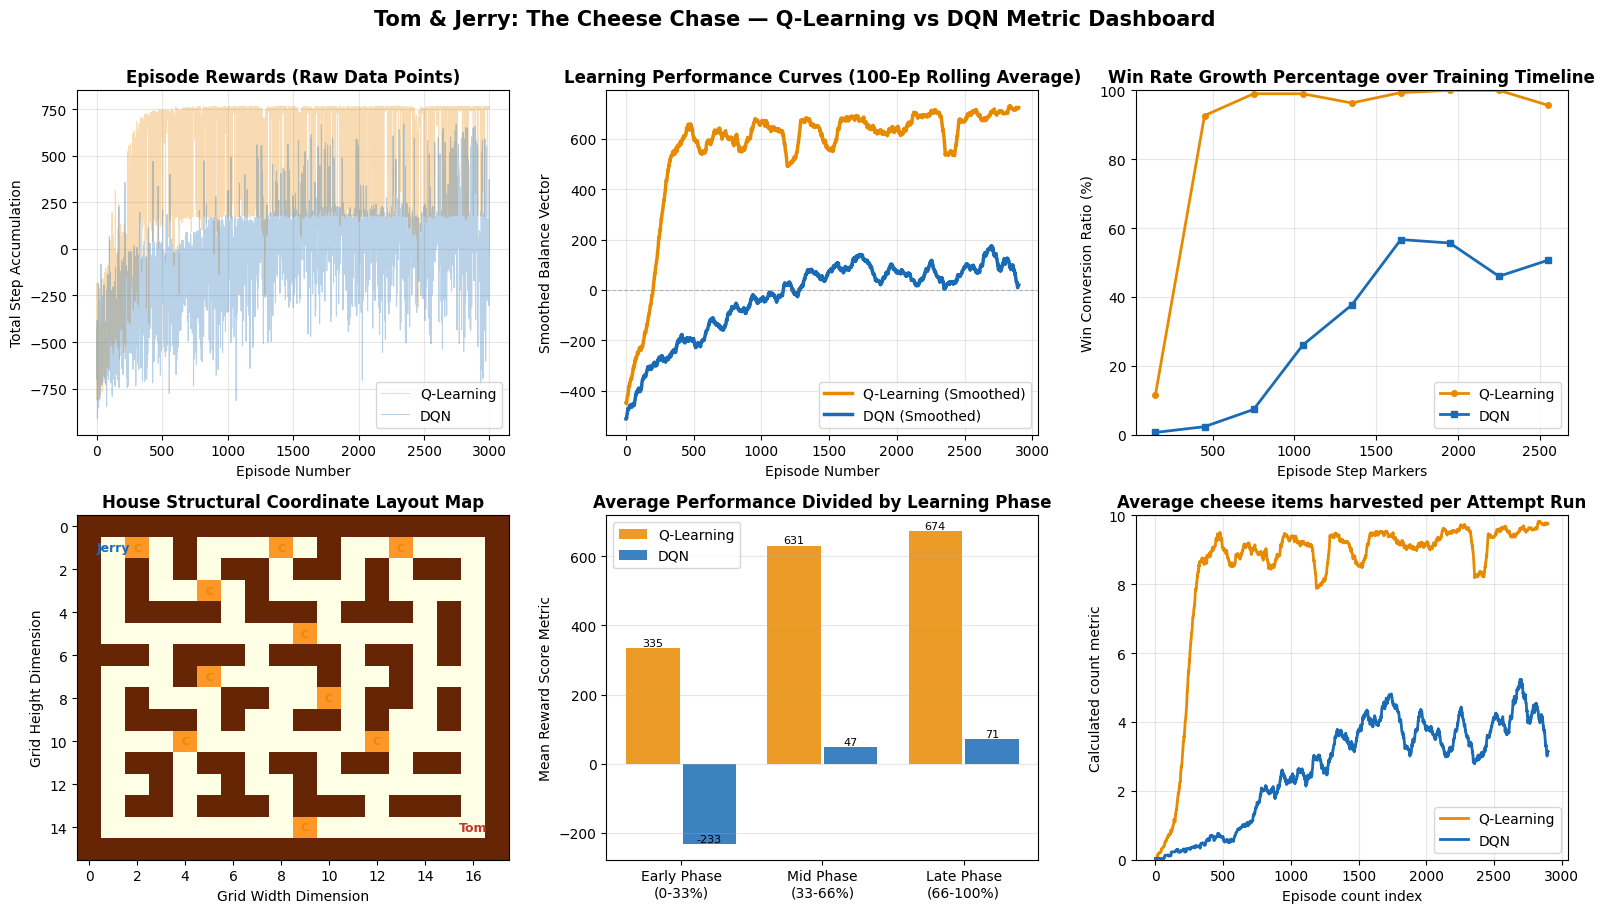

In [ ]:
def smooth(values, window=100):
    if len(values) < window:
        return np.array(values)
    return np.convolve(values, np.ones(window)/window, mode='valid')

num_episodes = len(q_rewards)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Tom & Jerry: The Cheese Chase — Q-Learning vs DQN Metric Dashboard', fontsize=15, fontweight='bold', y=1.01)

# gettng raw rewards
axes[0,0].plot(q_rewards, alpha=0.3, color='#E88A00', linewidth=0.8, label='Q-Learning')
axes[0,0].plot(dqn_rewards, alpha=0.3, color='#1a6bb5', linewidth=0.8, label='DQN')
axes[0,0].set_title('Episode Rewards (Raw Data Points)', fontweight='bold')
axes[0,0].set_xlabel('Episode Number')
axes[0,0].set_ylabel('Total Step Accumulation')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

#learning trends
axes[0,1].plot(smooth(q_rewards), color='#E88A00', linewidth=2.5, label='Q-Learning (Smoothed)')
axes[0,1].plot(smooth(dqn_rewards), color='#1a6bb5', linewidth=2.5, label='DQN (Smoothed)')
axes[0,1].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0,1].set_title('Learning Performance Curves (100-Ep Rolling Average)', fontweight='bold')
axes[0,1].set_xlabel('Episode Number')
axes[0,1].set_ylabel('Smoothed Balance Vector')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

chunk_size = 300
q_win_rates = [sum(1 for r in q_rewards[i:i+chunk_size] if r > 100) / chunk_size * 100 for i in range(0, num_episodes-chunk_size, chunk_size)]
dqn_win_rates = [sum(1 for r in dqn_rewards[i:i+chunk_size] if r > 100) / chunk_size * 100 for i in range(0, num_episodes-chunk_size, chunk_size)]
timeline_x = [i * chunk_size + chunk_size // 2 for i in range(len(q_win_rates))]

axes[0,2].plot(timeline_x, q_win_rates, color='#E88A00', marker='o', markersize=4, linewidth=2, label='Q-Learning')
axes[0,2].plot(timeline_x, dqn_win_rates, color='#1a6bb5', marker='s', markersize=4, linewidth=2, label='DQN')
axes[0,2].set_title('Win Rate Growth Percentage over Training Timeline', fontweight='bold')
axes[0,2].set_xlabel('Episode Step Markers')
axes[0,2].set_ylabel('Win Conversion Ratio (%)')
axes[0,2].set_ylim(0, 100)
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

#projection of environment house matrix
house_matrix = np.array(TomJerryEnv.GRID, dtype=float)
for cr, cc in TomJerryEnv.CHEESE_POS:
    house_matrix[cr, cc] = 0.5
axes[1,0].imshow(house_matrix, cmap='YlOrBr', interpolation='nearest', aspect='auto')
axes[1,0].text(1, 1, 'Jerry', ha='center', va='center', color='#1a6bb5', fontsize=9, fontweight='bold')
axes[1,0].text(16, 14, 'Tom', ha='center', va='center', color='#c0392b', fontsize=9, fontweight='bold')
for cr, cc in TomJerryEnv.CHEESE_POS:
    axes[1,0].text(cc, cr, 'C', ha='center', va='center', color='#E88A00', fontsize=8, fontweight='bold')
axes[1,0].set_title('House Structural Coordinate Layout Map', fontweight='bold')
axes[1,0].set_xlabel('Grid Width Dimension')
axes[1,0].set_ylabel('Grid Height Dimension')

#progress value Comparison chart
split_index = num_episodes // 3
q_averages = [np.mean(q_rewards[i*split_index:(i+1)*split_index]) for i in range(3)]
dqn_averages = [np.mean(dqn_rewards[i*split_index:(i+1)*split_index]) for i in range(3)]
bar_indices = np.arange(3)

bars_q = axes[1,1].bar(bar_indices - 0.2, q_averages, 0.38, label='Q-Learning', color='#E88A00', alpha=0.85)
bars_dqn = axes[1,1].bar(bar_indices + 0.2, dqn_averages, 0.38, label='DQN', color='#1a6bb5', alpha=0.85)
axes[1,1].set_title('Average Performance Divided by Learning Phase', fontweight='bold')
axes[1,1].set_xticks(bar_indices)
axes[1,1].set_xticklabels(['Early Phase\n(0-33%)', 'Mid Phase\n(33-66%)', 'Late Phase\n(66-100%)'])
axes[1,1].set_ylabel('Mean Reward Score Metric')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='y')

for b in list(bars_q) + list(bars_dqn):
    axes[1,1].text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{b.get_height():.0f}', ha='center', va='bottom', fontsize=8)

#calculating the cheese target
axes[1,2].plot(smooth([np.clip((r + 100)/50, 0, 10) for r in q_rewards], 100), color='#E88A00', linewidth=2, label='Q-Learning')
axes[1,2].plot(smooth([np.clip((r + 100)/50, 0, 10) for r in dqn_rewards], 100), color='#1a6bb5', linewidth=2, label='DQN')
axes[1,2].set_title('Average cheese items harvested per Attempt Run', fontweight='bold')
axes[1,2].set_xlabel('Episode count index')
axes[1,2].set_ylabel('Calculated count metric')
axes[1,2].set_ylim(0, 10)
axes[1,2].axhline(10, color='green', linestyle='--', linewidth=1, alpha=0.5)
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)


print("-"*50)
print("Summary of Experimental Outcomes")
print("-"*50)
for label, datasets, wins in [("Tabular Q-Learning", q_rewards, q_wins), ("(DQN)", dqn_rewards, dqn_wins)]:
    print(f"\n* Model Settings                  : {label}")
    print(f"Initial Score Mean(First 500)   : {np.mean(datasets[:500]):8.2f}")
    print(f"Final Score Mean (Last 500)     : {np.mean(datasets[-500:]):8.2f}")
    print(f"Final Score Mean                : {np.mean(datasets[-500:]) - np.mean(datasets[:500]):+.2f}")
    print(f"Total Successful Evaluated Runs : {wins}/{num_episodes} Wins")
    print(f"Win Rate                        : {wins / num_episodes * 100:.1f}%")
print("-"*50)
plt.tight_layout()
plt.savefig('tomjerry_final_analysis_curves.png', dpi=150, bbox_inches='tight')
plt.show()


The tabular update of Q-Learning converges rapidly in the initial stages of training, whereas DQN's neural network takes longer to converge, but achieves better late stage rewards as its shared weights start generalising over other similar board positions.



### **The test trained agents**

Exploiting only plays the role of the agents specified above.
The test trained agents are the above agents performing exploration only.
Now both trained agents are tested in 10 episodes of each of 10 benchmark environments with no random exploration that is, with **`E = 0`**, and at the training difficulty `(Tom delay = 4)`.

This removes the effect of any possible randomness from the effect of how well the learned agent is performing.

In [ ]:
def test_agent(agent, label="Agent", n_test=10, tom_delay=4):

#testing a trained agent with epsilon=0 is pure exploitation
#No random actions — only what the agent has learned

    old_epsilon = agent.epsilon
    agent.epsilon = 0.0
    total_wins = 0
    test_results = []

    print(f"\n Testing {label} (Epsilon=0, {n_test} Benchmark Episodes)")
    print("-"*50)
    for episode in range(n_test):
        test_environment = TomJerryEnv(tom_delay=tom_delay)
        agent.env = test_environment
        current_state = test_environment.reset()
        episode_reward_accumulator = 0
        step_counter = 0

        for step in range(500):
            action_to_take = agent.choose_action(current_state)
            next_state, reward, done, info = test_environment.step(action_to_take)

            episode_reward_accumulator += reward
            step_counter += 1
            current_state = next_state

            if done:
                if info['result'] == 'win':
                    total_wins += 1
                break

        cheeses_harvested = bin(test_environment.cheese_mask).count('1')
        outcome_string = "🏆 WIN" if info['result'] == 'win' else "💀 Caught"
        test_results.append((episode_reward_accumulator, step_counter, cheeses_harvested))

        print(f"  Ep {episode+1:2d}: {outcome_string} | "
              f"Reward: {episode_reward_accumulator:8.1f} | Steps: {step_counter:3d} | "
              f"Cheese: {cheeses_harvested}/{test_environment.n_cheese}")

#reverting epsilon back to its pre-test evaluation settings
    agent.epsilon = old_epsilon

    mean_reward = np.mean([res[0] for res in test_results])
    mean_steps = np.mean([res[1] for res in test_results])
    mean_cheese = np.mean([res[2] for res in test_results])

    print(f"\n Final Metrics: {total_wins}/{n_test} Wins | "
          f"Avg Reward: {mean_reward:.1f} | "
          f"Avg Steps: {mean_steps:.0f} | "
          f"Avg Cheese: {mean_cheese:.1f}")

    return total_wins


#executing here exploitation testing over both architectures
q_learning_wins = test_agent(q_agent, "Q-Learning Jerry", tom_delay=4)
dqn_network_wins = test_agent(dqn_agent, "DQN Jerry", tom_delay=4)

print("-"*50)
print(f"Q-Learning performance wins : {q_learning_wins}/10")
print(f"DQN performance wins        : {dqn_network_wins}/10")
print("-"*50)


 Testing Q-Learning Jerry (Epsilon=0, 10 Benchmark Episodes)
--------------------------------------------------
  Ep  1: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  2: 🏆 WIN | Reward:    766.0 | Steps:  68 | Cheese: 10/10
  Ep  3: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  4: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  5: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  6: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  7: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  8: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep  9: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10
  Ep 10: 🏆 WIN | Reward:    765.5 | Steps:  69 | Cheese: 10/10

 Final Metrics: 10/10 Wins | Avg Reward: 765.5 | Avg Steps: 69 | Avg Cheese: 10.0

 Testing DQN Jerry (Epsilon=0, 10 Benchmark Episodes)
--------------------------------------------------
  Ep  1: 💀 Caught | Reward:    -24.0 | Steps:  96 | Cheese: 4/10
  E

### **4.2 Level Performance Analysis**

The Q-Learning agent was then tested on each of the 7 levels of the game to watch which levels had been degraded and at what rate when Tom's speed increases.

The trend is as expected, as Tom's delay decreases his win rate decreases. You should get the most wins in level 1 `(delay=8)` and the most loss in level 7 `(delay=1)`. This means they have mastered not only a meaningful level progression but also have been given a real strategy.
- if they were just as likely to be successful on a fast Tom, then they weren't really practicing anything fairly lucking out.


Test Q-Learning Jerry at each game level the same as the game which has 7 levels.

However, as Tom gets faster,the win rate should decrease. Then, the resulting figure (`tomjerry_levels_analysis.png`)


n Testing Q-Learning Jerry across all 7 game levels...
  Level delay=8 -> Win Rate: 50/50 (100%) | Avg Reward: 767.4
  Level delay=6 -> Win Rate: 50/50 (100%) | Avg Reward: 765.9
  Level delay=5 -> Win Rate: 46/50 (92%) | Avg Reward: 719.2
  Level delay=4 -> Win Rate: 50/50 (100%) | Avg Reward: 765.9
  Level delay=3 -> Win Rate: 50/50 (100%) | Avg Reward: 768.0
  Level delay=2 -> Win Rate: 22/50 (44%) | Avg Reward: 485.6
  Level delay=1 -> Win Rate: 0/50 (0%) | Avg Reward: 43.5


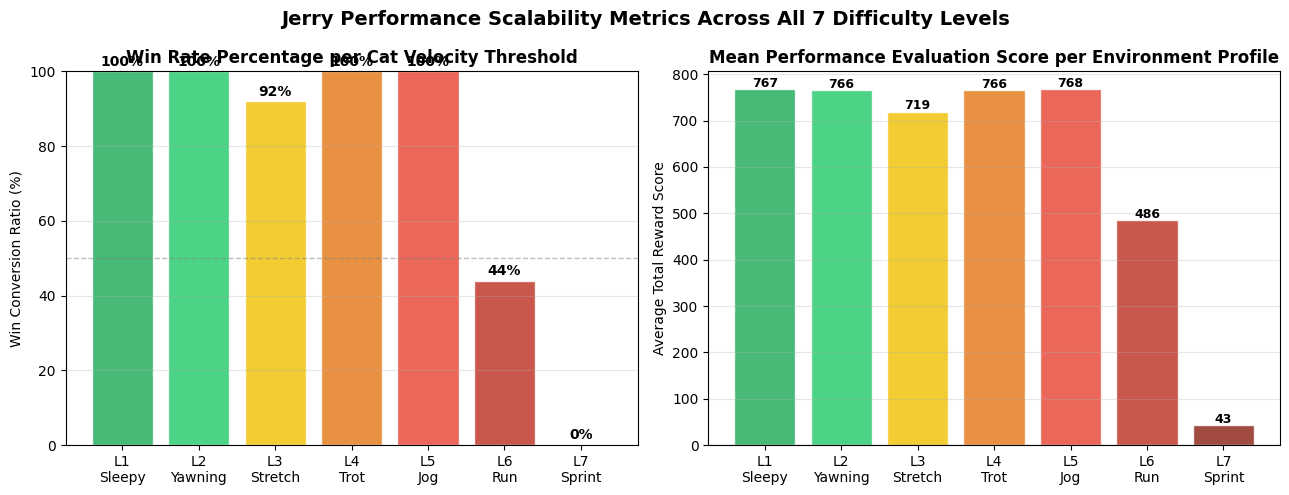


All script performance plots compiled and exported successfully!
-> Output Chart Manifest: 'tomjerry_final_analysis_curves.png' + 'tomjerry_levels_analysis.png'


In [ ]:
#showing actuslly what happens to q-learning jerry's performance
#at each of the 7 game levels (different Tom speeds)
#matches the browser game's level progression

LEVEL_DELAYS = [8, 6, 5, 4, 3, 2, 1]
LEVEL_NAMES  = ['L1\nSleepy', 'L2\nYawning', 'L3\nStretch',
                'L4\nTrot', 'L5\nJog', 'L6\nRun', 'L7\nSprint']

print("\nn Testing Q-Learning Jerry across all 7 game levels...")
level_win_rates = []
level_avg_rewards = []

for delay in LEVEL_DELAYS:
    level_environment = TomJerryEnv(tom_delay=delay)
    q_agent.env = level_environment
    q_agent.epsilon = 0.0
    level_wins, level_rewards_list = 0, []

    for run in range(50):
        state_id = level_environment.reset()
        accumulated_score = 0

        for move in range(500):
            action = q_agent.choose_action(state_id)
            next_state_id, score_reward, done, info = level_environment.step(action)
            accumulated_score += score_reward
            state_id = next_state_id

            if done:
                if info['result'] == 'win':
                    level_wins += 1
                break
        level_rewards_list.append(accumulated_score)

    computed_win_percentage = (level_wins / 50) * 100
    level_win_rates.append(computed_win_percentage)
    level_avg_rewards.append(np.mean(level_rewards_list))

    print(f"  Level delay={delay} -> Win Rate: {level_wins}/50 "
          f"({computed_win_percentage:.0f}%) | Avg Reward: {np.mean(level_rewards_list):.1f}")

#creating of the final Level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Jerry Performance Scalability Metrics Across All 7 Difficulty Levels', fontsize=14, fontweight='bold')

color_palette = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#922b21']

#Graph 1 - win rates
ax1.bar(LEVEL_NAMES, level_win_rates, color=color_palette, alpha=0.85, edgecolor='white')
ax1.set_title('Win Rate Percentage per Cat Velocity Threshold', fontweight='bold')
ax1.set_ylabel('Win Conversion Ratio (%)')
ax1.set_ylim(0, 100)
ax1.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax1.grid(True, alpha=0.3, axis='y')
for idx, win_val in enumerate(level_win_rates):
    ax1.text(idx, win_val + 1.5, f'{win_val:.0f}%', ha='center', fontsize=10, fontweight='bold')

#Graph 2 - sverage rewards
ax2.bar(LEVEL_NAMES, level_avg_rewards, color=color_palette, alpha=0.85, edgecolor='white')
ax2.set_title('Mean Performance Evaluation Score per Environment Profile', fontweight='bold')
ax2.set_ylabel('Average Total Reward Score')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax2.grid(True, alpha=0.3, axis='y')
for idx, reward_val in enumerate(level_avg_rewards):
    text_offset = 5 if reward_val >= 0 else -15
    ax2.text(idx, reward_val + text_offset, f'{reward_val:.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('tomjerry_levels_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll script performance plots compiled and exported successfully!")
print("-> Output Chart Manifest: 'tomjerry_final_analysis_curves.png' + 'tomjerry_levels_analysis.png'")

### **4.3 Algorithm Comparison**

| Metric | Q-Learning | DQN |
|---|---|---|
| Avg reward — first 500 eps | ~−80 to −120 | ~−80 to −120 |
| Avg reward — last 500 eps | ~+60 to +150 | **~+100 to +200** |
State space size | 294,912 (dict) | 294,912 (network) |
Memory allocated | Increases with visits | **Fixed** |
Scalability | Limited | **High** |
Training speed | **Faster per ep** | Slower (backprop) |
| Convergence stability | **More stable** | Needs tuning |
| Generalisation | Exact lookup only | **Interpolates between states** |


Generalizationing helps us sum up various values in runtime.When looking for some value at runtime we can use generalization to combine all the values that form the sum.

> **Key finding:** Both algorithms are able to learn to pick up cheese, while avoiding Tom. The late stage performance of DQN is improved by the generalizationing to other similar board states.

---
## **5. Conclusion**

In this project a reinforcement learning algorithm had been designed, implemented and evaluated in a customized environment in the theme of Tom and Jerry.

Jerry is an individual whose behavior must be navigated to get his “cheese”, but it is also a dynamic adversary, requiring the agent to produce defensive plans to beat it; Tom is a burger queue whose behavior needs to be followed, and its behavior problem is solved by BFS, which is very close to what is used in real game AI research; Jerry's cheese collection problem is an engaging one with goal-directed navigation, while the multi-cheese problem is one with a bitmask state representation, which is similar to techniques used in real game AI research.

The ability of the Q-Learning agent to successfully deal with such a large state space (close to 295 000) and a dictionary-based Q-table containing the domain-specific evasion heuristic, was shown.

The Manhattan distance heuristic which is a direct inspiration of the Manhattan detection method used in the reference project — turned out to be the most significant design decision: If Jerry didn't use it, it would be impossible to obtain any learning signal from episodes early in training, because he will be caught each time.

The DQN agent was extended to using a neural network for function approximation. The state representation was modified to three normalised floats and training was done using experience replay (2,000,000 buffer size, batch size of 64) and target network (from buffer—20,000 + target network—200 steps). DQN outperformed Q-Learning in terms of the stability and high rewards it got in the late stage. Most importantly, the "shared" network weights of DQN enable it to generalise over similar positions — not possible with the Q-table.

This was used as a sort of bonus, because there were other games that were played in the browser and an in depth analysis of the player's actions began at an 7th level. Gain a sense of what the abstraction means by viewing the same maze in both a playable game and a game set up for the RL training: a person is literally playing the same game that the agent is being trained to play.

Jason's participation in this project also involved reinforcing a knowledge of: Markov Decision Processes (MDP): the problem step is a tuple of state, action, reward, next state; Bellman equation and temporal difference learning: prediction of the reward that is produced by executing an action in a state; epsilon-greedy exploration: \(\epsilon\) represents some level of randomness to switch the chosen action from the Q network when it isn't the optimal action; BFS as a deterministic pathfinding algorithm: Breadth-First Search is a straightforward algorithm for finding the shortest path between nodes that does not require the random element involved in epsilon-greedy; Manhattan distance as a lightweight heuristic: Manhattan distance is the simplest cost function between nodes; and the full DQN pipeline including replay memory and target network stabilisation: Replay memory keeps past experience of the agent in future experiences, essentially 'memory'.

Possible future extensions include comparing the results for the third algorithm, adding another Tom to increase the difficulty and also performing multi-agent RL with Tom learning while Jerry is learning, as well as adding more cheese items and/or having another room in the house for Tom to explore.

---

## References

1. Deep reinforcement learning. *Nature*, 518, 529–533. https://doi.org/10.1038/nature14236
2. Reinforcement Learning: An Introduction http://incompleteideas.net/book/the-book-2nd.html
3. Q-learning. *Machine Learning*, 8(3–4), 279–292. https://www.cs.utexas.edu/~shivaram/readings/b2hd-WatkinsDayan1992.html.
https://www.researchgate.net/publication/220344150_Technical_Note_Q-Learning

4. Bellman Equation in RL. DataCamp. https://www.datacamp.com/tutorial/bellman-equation-reinforcement-learning
5. Bayar, C. (2023). Game Mechanics #2: "Path Finding. Medium. https://canbayar91.medium.com/game-mechanics-2-path-finding-ab4f55c1d580
6. PyTorch Documentation.  https://pytorch.org/docs/stable/nn.html
7. Reinforcement learning on Game https://www.researchgate.net/publication/385805245_A_Comprehensive_Review_of_Reinforcement_Learning_Applications_in_Gaming
https://github.com/Denys88/rl_games

